In [1]:
# 1. Importing Python Modules/Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score

In [2]:
# 2. Importing data
df = pd.read_csv("datasets/iris.csv")
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (150, 5)


,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


In [3]:
# 3. Displaying data
print("First 5 rows:")
display(df.head())

print("\nDataset Info:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

First 5 rows:


,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal.length  150 non-null    float64
 1   sepal.width   150 non-null    float64
 2   petal.length  150 non-null    float64
 3   petal.width   150 non-null    float64
 4   variety       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB

Missing values:
sepal.length    0
sepal.width     0
petal.length    0
petal.width     0
variety         0
dtype: int64


Statistical Summary:


,sepal.length,sepal.width,petal.length,petal.width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


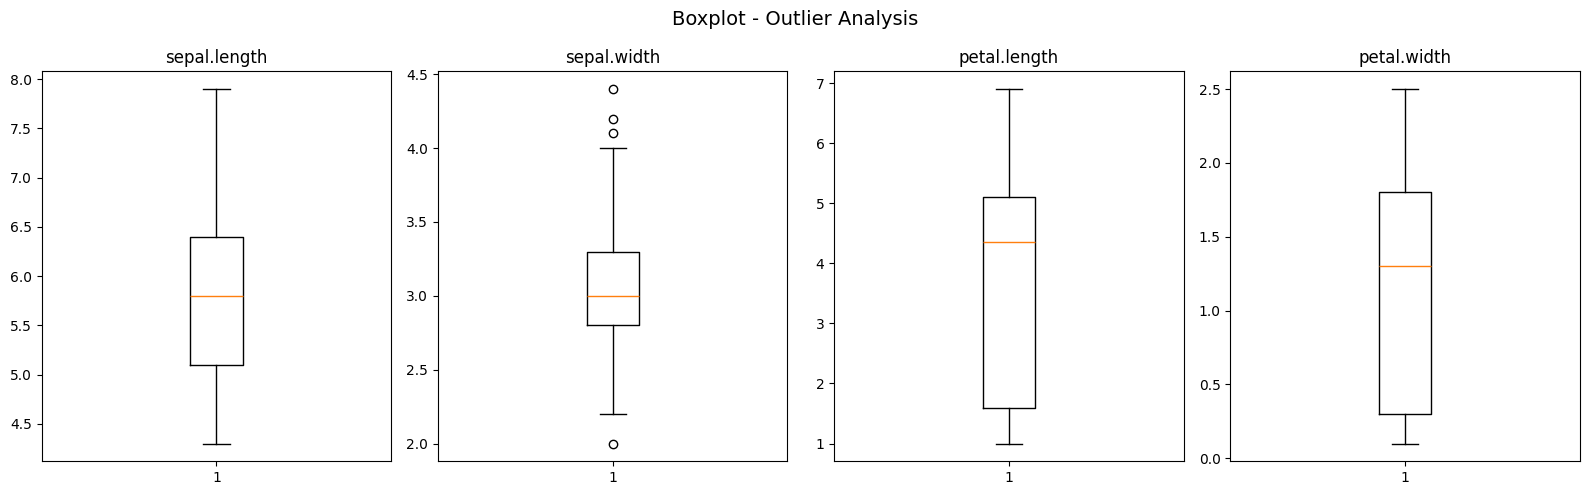


Outlier count (IQR method):
  sepal.length: 0 outliers
  sepal.width: 4 outliers
  petal.length: 0 outliers
  petal.width: 0 outliers


In [4]:
# 4. Statistical Analysis & Outlier Analysis
print("Statistical Summary:")
display(df.describe())

# Outlier analysis using boxplots
numeric_cols = df.select_dtypes(include=np.number).columns
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(16, 5))
for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col], vert=True)
    axes[i].set_title(col)
plt.suptitle("Boxplot - Outlier Analysis", fontsize=14)
plt.tight_layout()
plt.show()

# Detecting outliers using IQR method
print("\nOutlier count (IQR method):")
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"  {col}: {len(outliers)} outliers")

In [5]:
# 5. Creating the Independent and Dependent variables
X = df.iloc[:, :-1]   # All columns except the last one (features)
y = df.iloc[:, -1]    # Last column (target/variety)

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print(f"Target classes: {y.unique()}")

Features (X) shape: (150, 4)
Target (y) shape: (150,)
Target classes: ['Setosa' 'Versicolor' 'Virginica']


In [6]:
# 6. Replacing missing values with meaningful value
X.fillna(X.mean(numeric_only=True), inplace=True)
print("Missing values after imputation:")
print(X.isnull().sum())

Missing values after imputation:
sepal.length    0
sepal.width     0
petal.length    0
petal.width     0
dtype: int64


In [7]:
# 7. Encoding categorical data
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Label Encoding:")
for cls, label in zip(le.classes_, le.transform(le.classes_)):
    print(f"  {cls} -> {label}")

Label Encoding:
  Setosa -> 0
  Versicolor -> 1
  Virginica -> 2


In [8]:
# 8. Splitting the data into training and test set
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print("Feature scaling complete.")

Training set size: 120
Test set size: 30
Feature scaling complete.


SVM Classifier Results:
Accuracy: 1.0000

              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       1.00      1.00      1.00         9
   Virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



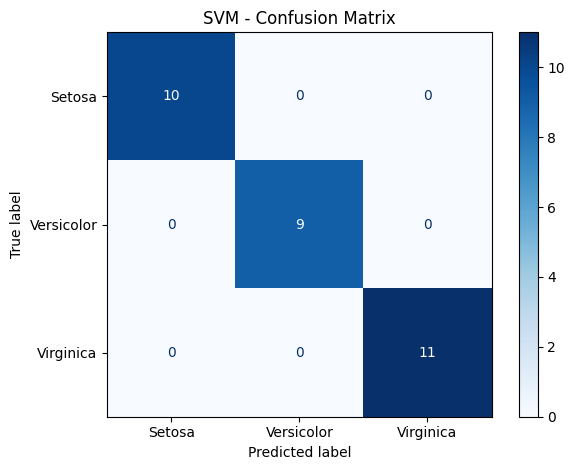

In [9]:
# 9. Implement SVM
svm_clf = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
svm_clf.fit(X_train_scaled, y_train)

y_pred_svm = svm_clf.predict(X_test_scaled)
svm_acc = accuracy_score(y_test, y_pred_svm)

print("SVM Classifier Results:")
print(f"Accuracy: {svm_acc:.4f}\n")
print(classification_report(y_test, y_pred_svm, target_names=le.classes_))

cm_svm = confusion_matrix(y_test, y_pred_svm)
ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=le.classes_).plot(cmap='Blues')
plt.title("SVM - Confusion Matrix")
plt.tight_layout()
plt.show()

Decision Tree Classifier Results:
Accuracy: 1.0000

              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       1.00      1.00      1.00         9
   Virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



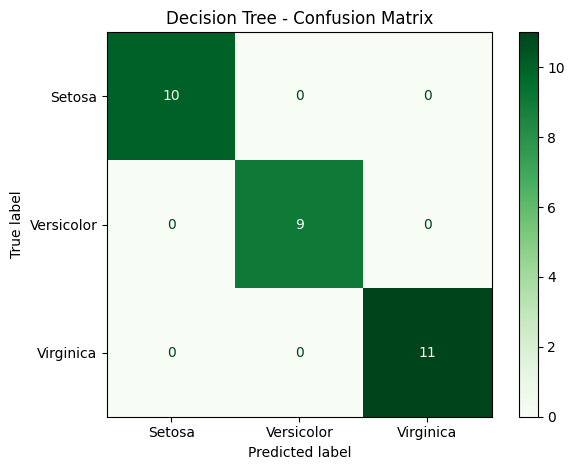


Comparison: SVM vs Decision Tree
   Classifier  Accuracy
          SVM       1.0
Decision Tree       1.0

Better classifier: SVM


In [10]:
# 10. Perform comparison with Decision Tree
dt_clf = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_clf.fit(X_train_scaled, y_train)

y_pred_dt = dt_clf.predict(X_test_scaled)
dt_acc = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Classifier Results:")
print(f"Accuracy: {dt_acc:.4f}\n")
print(classification_report(y_test, y_pred_dt, target_names=le.classes_))

cm_dt = confusion_matrix(y_test, y_pred_dt)
ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=le.classes_).plot(cmap='Greens')
plt.title("Decision Tree - Confusion Matrix")
plt.tight_layout()
plt.show()

# Comparison Summary
print("\n" + "="*50)
print("Comparison: SVM vs Decision Tree")
print("="*50)
comparison = pd.DataFrame({
    "Classifier": ["SVM", "Decision Tree"],
    "Accuracy": [svm_acc, dt_acc]
})
print(comparison.to_string(index=False))
print(f"\nBetter classifier: {'SVM' if svm_acc >= dt_acc else 'Decision Tree'}")

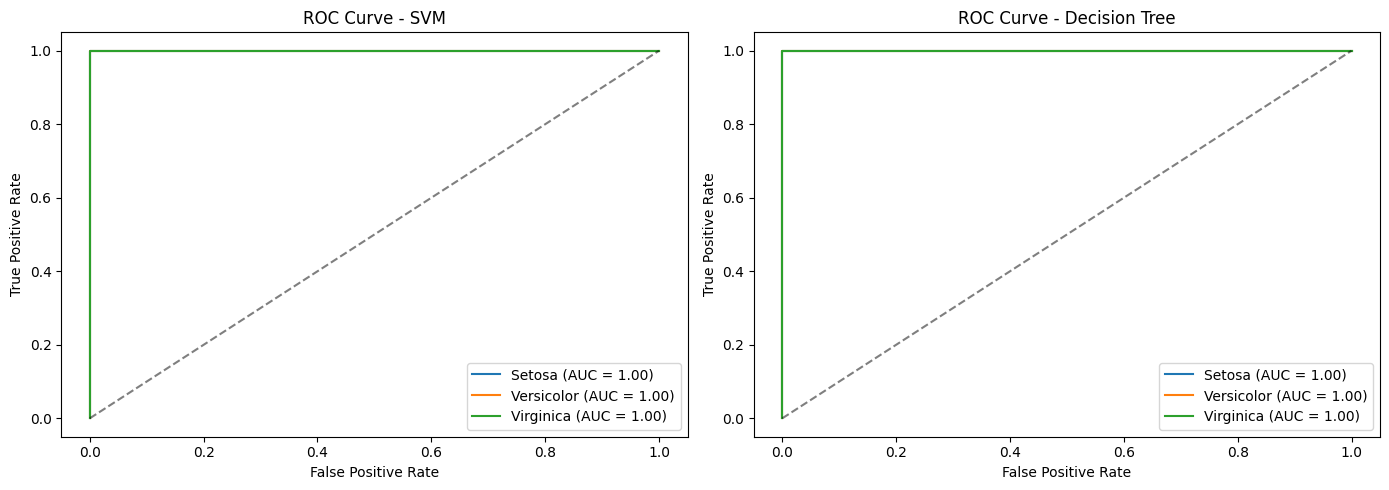

In [11]:
# 11. ROC Curve - SVM vs Decision Tree
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize the test labels for multi-class ROC
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = y_test_bin.shape[1]

# Get probability scores
y_prob_svm = svm_clf.predict_proba(X_test_scaled)
y_prob_dt = dt_clf.predict_proba(X_test_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_prob, title in zip(axes, [y_prob_svm, y_prob_dt], ["SVM", "Decision Tree"]):
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, label=f"{le.classes_[i]} (AUC = {roc_auc:.2f})")
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(f"ROC Curve - {title}")
    ax.legend(loc="lower right")

plt.tight_layout()
plt.show()